Task 1: Missing Data – Titanic Dataset

Dataset: Titanic - Machine Learning from Disaster

Introduction

Goal: Handle missing values.

Techniques: Mean/Median (Age), Mode (Embarked), Drop Column (Cabin).

Reason: Different data types require different imputation strategies.

In [9]:
# Import libraries
import pandas as pd
import numpy as np

# Load dataset
df = pd.read_csv("/kaggle/input/competitions/titanic/train.csv")

# Display basic info
print("Shape of dataset:", df.shape)
print("\nMissing Values Before Handling:\n")
print(df.isnull().sum())

Shape of dataset: (891, 12)

Missing Values Before Handling:

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


In [10]:
#Mean Imputation (Age)
df_mean = df.copy()
df_mean['Age'] = df_mean['Age'].fillna(df_mean['Age'].mean())
df_mean['Age'].isnull().sum()

np.int64(0)

In [11]:
#Median Imputation (Age)
df_median = df.copy()
df_median['Age'] = df_median['Age'].fillna(df_median['Age'].median())
df_median['Age'].isnull().sum()

np.int64(0)

Task 2: Feature Encoding – Car Evaluation Dataset
🔹 Introduction

Task Overview:
The objective of this task is to encode categorical variables in the Car Evaluation dataset to make them suitable for machine learning algorithms.

Chosen Techniques & Reason:

Label Encoding → Converts categories into numeric form but may introduce ordinal relationships.

One-Hot Encoding → Removes ordinal bias by creating binary indicator columns.

Both techniques are implemented and compared.

In [17]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder

df = pd.read_csv("/kaggle/input/datasets/rohit265/car-evaluation-uci-machine-learning/car.csv")

df.head()

,Unnamed: 0,buying,maint,doors,persons,lug_boots,safety,Class
0,0,vhigh,vhigh,2,2,small,low,unacc
1,1,vhigh,vhigh,2,2,small,med,unacc
2,2,vhigh,vhigh,2,2,small,high,unacc
3,3,vhigh,vhigh,2,2,med,low,unacc
4,4,vhigh,vhigh,2,2,med,med,unacc


In [18]:
#Label Encoding
df_label = df.copy()

le = LabelEncoder()

for col in df_label.columns:
    df_label[col] = le.fit_transform(df_label[col])

df_label.head()

#⃣ One-Hot Encoding
df_onehot = pd.get_dummies(df)

df_onehot.head()

,Unnamed: 0,buying_high,buying_low,buying_med,buying_vhigh,maint_high,maint_low,maint_med,maint_vhigh,doors_2,...,lug_boots_big,lug_boots_med,lug_boots_small,safety_high,safety_low,safety_med,Class_acc,Class_good,Class_unacc,Class_vgood
0,0,False,False,False,True,False,False,False,True,True,...,False,False,True,False,True,False,False,False,True,False
1,1,False,False,False,True,False,False,False,True,True,...,False,False,True,False,False,True,False,False,True,False
2,2,False,False,False,True,False,False,False,True,True,...,False,False,True,True,False,False,False,False,True,False
3,3,False,False,False,True,False,False,False,True,True,...,False,True,False,False,True,False,False,False,True,False
4,4,False,False,False,True,False,False,False,True,True,...,False,True,False,False,False,True,False,False,True,False


Task 3: Feature Scaling – Wine Quality Dataset
🔹 Introduction

Task Overview:
The objective of this task is to apply feature scaling techniques to the Wine Quality dataset and analyze how scaling affects numerical feature distributions.

Chosen Techniques & Reason:

Standardization (Z-score Scaling) → Centers data around mean 0 with unit variance. Suitable when features follow Gaussian-like distribution.

Min-Max Normalization → Scales data to range [0,1]. Useful when bounded scaling is required.

Scaling is necessary because features have different magnitudes and units.

In [20]:
#Data Loading & Preprocessing Steps Only
#Step 1: Load Dataset
import pandas as pd
from sklearn.preprocessing import StandardScaler, MinMaxScaler

# Load dataset
df = pd.read_csv("/kaggle/input/datasets/yasserh/wine-quality-dataset/WineQT.csv")

df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,1
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,2
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,3
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,4


In [21]:
#Separate Features and Target
X = df.drop('quality', axis=1)
y = df['quality']

#⃣ Standardization
scaler_std = StandardScaler()
X_standardized = scaler_std.fit_transform(X)

# Convert back to DataFrame
X_standardized = pd.DataFrame(X_standardized, columns=X.columns)

X_standardized.head()

#️⃣ Min-Max Normalization
scaler_norm = MinMaxScaler()
X_normalized = scaler_norm.fit_transform(X)

# Convert back to DataFrame
X_normalized = pd.DataFrame(X_normalized, columns=X.columns)

X_normalized.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,Id
0,0.247788,0.397260,0.00,0.068493,0.106845,0.149254,0.098940,0.567548,0.606299,0.137725,0.153846,0.000000
1,0.283186,0.520548,0.00,0.116438,0.143573,0.358209,0.215548,0.494126,0.362205,0.209581,0.215385,0.000626
2,0.283186,0.438356,0.04,0.095890,0.133556,0.208955,0.169611,0.508811,0.409449,0.191617,0.215385,0.001252
3,0.584071,0.109589,0.56,0.068493,0.105175,0.238806,0.190813,0.582232,0.330709,0.149701,0.215385,0.001879
4,0.247788,0.397260,0.00,0.068493,0.106845,0.149254,0.098940,0.567548,0.606299,0.137725,0.153846,0.002505


Task 4: Handling Outliers – Boston Housing Dataset
🔹 Introduction

Task Overview:
The goal of this task is to detect and handle outliers in the Boston Housing dataset to improve model performance.

Chosen Techniques & Reason:

Z-Score Method → Identifies points far from the mean (sensitive to extreme outliers).

IQR Method (Interquartile Range) → Detects outliers based on the spread of the middle 50% of the data, robust to skewed distributions.

In [25]:
#Data Loading & Preprocessing Steps Only
#Step 1: Load Dataset
import pandas as pd
import numpy as np

# Load Boston Housing dataset
df = pd.read_csv("/kaggle/input/datasets/schirmerchad/bostonhoustingmlnd/housing.csv")  # replace path if needed
df.head()
#Step 2: Check for basic stats
df.describe()

,RM,LSTAT,PTRATIO,MEDV
count,489.000000,489.000000,489.000000,4.890000e+02
mean,6.240288,12.939632,18.516564,4.543429e+05
std,0.643650,7.081990,2.111268,1.653403e+05
min,3.561000,1.980000,12.600000,1.050000e+05
25%,5.880000,7.370000,17.400000,3.507000e+05
50%,6.185000,11.690000,19.100000,4.389000e+05
75%,6.575000,17.120000,20.200000,5.187000e+05
max,8.398000,37.970000,22.000000,1.024800e+06


In [26]:
from scipy import stats

# Compute Z-scores
z_scores = np.abs(stats.zscore(df))

# Filter rows where all Z-scores < 3
df_zscore = df[(z_scores < 3).all(axis=1)]
df_zscore.shape

(472, 4)

In [27]:
Q1 = df.quantile(0.25)
Q3 = df.quantile(0.75)
IQR = Q3 - Q1

# Filter rows within 1.5*IQR
df_iqr = df[~((df < (Q1 - 1.5 * IQR)) | (df > (Q3 + 1.5 * IQR))).any(axis=1)]
df_iqr.shape

(444, 4)

Task 5: Data Imputation (Advanced) – Retail Sales Dataset
🔹 Introduction

Task Overview:
The goal of this task is to handle missing values in the Retail Sales dataset using advanced imputation techniques to improve model quality.

Chosen Techniques & Reason:

KNN Imputation → Fills missing values using similarity between rows.

MICE (Multiple Imputation by Chained Equations) → Generates multiple imputations for more robust handling of missing data.

These techniques are better than simple mean/median imputation when the dataset has complex patterns.

In [54]:
# Step 0: Import libraries
import pandas as pd
from sklearn.impute import KNNImputer
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer

# Step 1: Load dataset
df = pd.read_csv("/kaggle/input/datasets/mohammadtalib786/retail-sales-dataset/retail_sales_dataset.csv")  
# Step 2: Identify numeric and non-numeric columns
numeric_cols = df.select_dtypes(include='number').columns
non_numeric_cols = df.select_dtypes(exclude='number').columns

In [55]:
# Step 3: One-hot encode non-numeric columns
df_encoded = pd.get_dummies(df, columns=non_numeric_cols, drop_first=True)



In [50]:
# Step 4: KNN Imputation
knn_imputer = KNNImputer(n_neighbors=5)
df_knn = pd.DataFrame(knn_imputer.fit_transform(df_encoded), columns=df_encoded.columns)


In [51]:
# Check missing values
print("Missing values after KNN imputation:")
print(df_knn.isnull().sum())

Missing values after KNN imputation:
Transaction ID                  0
Age                             0
Quantity                        0
Price per Unit                  0
Total Amount                    0
                               ..
Customer ID_CUST998             0
Customer ID_CUST999             0
Gender_Male                     0
Product Category_Clothing       0
Product Category_Electronics    0
Length: 1351, dtype: int64


In [ ]:
# Check missing values
print("Missing values after MICE imputation:")
print(df_mice.isnull().sum())

Task 6: Feature Engineering – Heart Disease Dataset
🔹 Introduction

Task Overview:
The goal is to create new derived features from the existing ones to enhance predictive power for heart disease.

Chosen Techniques & Reason:

Age groups → Convert age into bins (Young, Middle, Senior) to capture non-linear effects.

Cholesterol categories → Categorize cholesterol values into “Normal”, “Borderline”, “High”.

Risk factors → Combine existing features (e.g., blood pressure + cholesterol) into a new risk indicator.

Feature engineering helps models capture patterns not visible in raw numeric data.

In [65]:
import pandas as pd
import numpy as np

# Load dataset
df = pd.read_csv("/kaggle/input/datasets/redwankarimsony/heart-disease-data/heart_disease_uci.csv")  # update path if needed
df.head()

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


In [66]:
# Fill numeric missing values with median
numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns
df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].median())

# Fill categorical missing values with mode
categorical_cols = df.select_dtypes(include='object').columns
for col in categorical_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

/tmp/ipykernel_55/2257369504.py:8: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[col] = df[col].fillna(df[col].mode()[0])


In [67]:
#Create Age Groups

bins = [0, 40, 60, 120]
labels = ['Young', 'Middle', 'Senior']
df['Age_group'] = pd.cut(df['age'], bins=bins, labels=labels)

In [68]:
#Create Cholesterol Categories
def cholesterol_cat(chol):
    if chol < 200:
        return 'Normal'
    elif 200 <= chol < 240:
        return 'Borderline'
    else:
        return 'High'

df['Cholesterol_cat'] = df['chol'].apply(cholesterol_cat)

In [72]:
#Create Risk Factor Feature
# Numeric feature combining age and cholesterol
df['Risk_factor'] = df['age'] * df['chol'] / 1000  # scaled

In [73]:
#One-Hot Encode Categorical Features
df = pd.get_dummies(df, columns=['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'thal', 'Age_group', 'Cholesterol_cat'], drop_first=True)
df.head()

,id,age,dataset,trestbps,chol,thalch,oldpeak,ca,num,Risk_factor,...,restecg_st-t abnormality,exang_True,slope_flat,slope_upsloping,thal_normal,thal_reversable defect,Age_group_Middle,Age_group_Senior,Cholesterol_cat_High,Cholesterol_cat_Normal
0,1,63,Cleveland,145.0,233.0,150.0,2.3,0.0,0,14.679,...,False,False,False,False,False,False,False,True,False,False
1,2,67,Cleveland,160.0,286.0,108.0,1.5,3.0,2,19.162,...,False,True,True,False,True,False,False,True,True,False
2,3,67,Cleveland,120.0,229.0,129.0,2.6,2.0,1,15.343,...,False,True,True,False,False,True,False,True,False,False
3,4,37,Cleveland,130.0,250.0,187.0,3.5,0.0,0,9.250,...,False,False,False,False,True,False,False,False,True,False
4,5,41,Cleveland,130.0,204.0,172.0,1.4,0.0,0,8.364,...,False,False,False,True,True,False,True,False,False,False


Task 7: Variable Transformation – Bike Sharing Dataset
🔹 Introduction

Task Overview:
Transform skewed numeric variables in the Bike Sharing dataset to reduce skewness and improve ML model performance.

Chosen Techniques & Reason:

Log Transformation: Reduces right skew in highly skewed variables.

Square Root Transformation: Moderate skew correction for count-type features.

Box-Cox Transformation: Applies more flexible power transformation for strictly positive data.

Variable transformation helps ML models converge faster and improves prediction accuracy.

In [74]:
#Data Loading & Preprocessing
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv("/kaggle/input/datasets/yasserh/bike-sharing-dataset/day.csv")  # update path if needed
df.head()

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,01-01-2018,1,0,1,0,6,0,2,14.110847,18.18125,80.5833,10.749882,331,654,985
1,2,02-01-2018,1,0,1,0,0,0,2,14.902598,17.68695,69.6087,16.652113,131,670,801
2,3,03-01-2018,1,0,1,0,1,1,1,8.050924,9.47025,43.7273,16.636703,120,1229,1349
3,4,04-01-2018,1,0,1,0,2,1,1,8.200000,10.60610,59.0435,10.739832,108,1454,1562
4,5,05-01-2018,1,0,1,0,3,1,1,9.305237,11.46350,43.6957,12.522300,82,1518,1600


In [80]:
df.columns

Index(['instant', 'dteday', 'season', 'yr', 'mnth', 'holiday', 'weekday',
       'workingday', 'weathersit', 'temp', 'atemp', 'hum', 'windspeed',
       'casual', 'registered', 'cnt', 'cnt_log', 'registered_log',
       'casual_log', 'windspeed_sqrt'],
      dtype='object')

In [75]:
#Identify Skewed Variables
# Select numeric columns
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns

# Check skewness
skew_values = df[numeric_cols].skew().sort_values(ascending=False)
print("Skewness of numeric columns:\n", skew_values)

Skewness of numeric columns:
 holiday       5.650014
casual        1.266328
weathersit    0.961855
windspeed     0.676314
registered    0.041211
weekday       0.002745
instant       0.000000
yr            0.000000
season       -0.002571
mnth         -0.010478
cnt          -0.049581
temp         -0.057187
hum          -0.067476
atemp        -0.133709
workingday   -0.790992
dtype: float64


In [82]:
# Apply sqrt transformation to humidity (hum)
df['hum_sqrt'] = np.sqrt(df['hum'])

In [83]:
from scipy.stats import boxcox

# Box-Cox requires strictly positive values
for col in ['temp', 'atemp']:
    df[col + '_boxcox'], _ = boxcox(df[col] + 1)  # shift by 1 to avoid zero

In [85]:
df[['cnt', 'cnt_log', 'registered', 'registered_log', 'casual', 'casual_log', 
    'windspeed', 'windspeed_sqrt', 'hum', 'hum_sqrt', 'temp', 'temp_boxcox', 
    'atemp', 'atemp_boxcox']].head()

,cnt,cnt_log,registered,registered_log,casual,casual_log,windspeed,windspeed_sqrt,hum,hum_sqrt,temp,temp_boxcox,atemp,atemp_boxcox
0,985,6.893656,654,6.484635,331,5.805135,10.749882,3.278701,80.5833,8.976820,14.110847,11.068389,18.18125,18.397370
1,801,6.687109,670,6.508769,131,4.882802,16.652113,4.080700,69.6087,8.343183,14.902598,11.623907,17.68695,17.894892
2,1349,7.207860,1229,7.114769,120,4.795791,16.636703,4.078811,43.7273,6.612662,8.050924,6.670304,9.47025,9.555044
3,1562,7.354362,1454,7.282761,108,4.691348,10.739832,3.277168,59.0435,7.683977,8.200000,6.782319,10.60610,10.706214
4,1600,7.378384,1518,7.325808,82,4.418841,12.522300,3.538686,43.6957,6.610272,9.305237,7.605749,11.46350,11.575598


Task 8: Feature Selection – Diabetes Dataset
🔹 Introduction

Task Overview:
Select the most relevant features to improve model performance and reduce overfitting.

Chosen Techniques & Reason:

Correlation Analysis: Identify highly correlated features and remove redundancy.

Mutual Information: Measures dependency between each feature and target.

Recursive Feature Elimination (RFE): Selects features iteratively using a model (e.g., logistic regression).

This ensures we keep features that contribute most to predicting diabetes.

Task 8: Feature Selection – Diabetes Dataset
🔹 Introduction

Task Overview:
Select the most relevant features to improve model performance and reduce overfitting.

Chosen Techniques & Reason:

Correlation Analysis: Identify highly correlated features and remove redundancy.

Mutual Information: Measures dependency between each feature and target.

Recursive Feature Elimination (RFE): Selects features iteratively using a model (e.g., logistic regression).

This ensures we keep features that contribute most to predicting diabetes.

In [1]:
#Data Loading & Preprocessing
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import mutual_info_classif, RFE
from sklearn.linear_model import LogisticRegression
import seaborn as sns
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv("/kaggle/input/datasets/jamaltariqcheema/pima-indians-diabetes-dataset/diabetes.csv")
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72.0,35,169.5,33.6,0.627,50,1
1,1,85,66.0,29,102.5,26.6,0.351,31,0
2,8,183,64.0,32,169.5,23.3,0.672,32,1
3,1,89,66.0,23,94.0,28.1,0.167,21,0
4,0,137,40.0,35,168.0,43.1,2.288,33,1


In [2]:
#Separate Features & Target
X = df.drop('Outcome', axis=1)  # features
y = df['Outcome']               # target

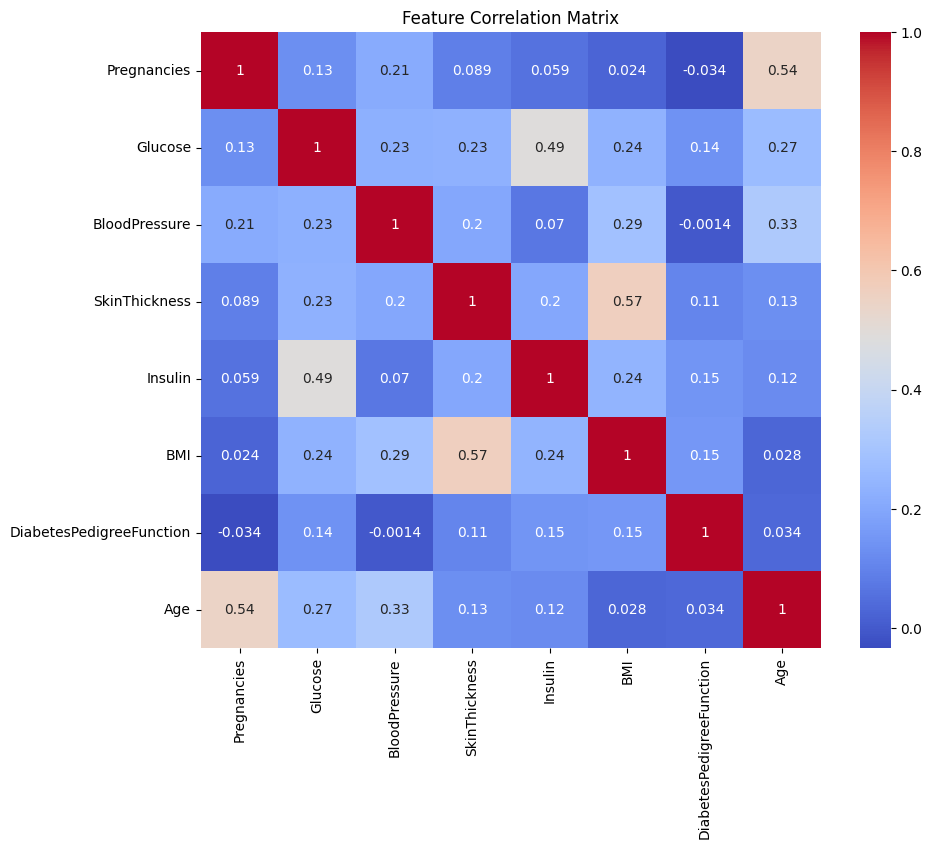

In [3]:
# Correlation matrix
corr_matrix = X.corr()
plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title("Feature Correlation Matrix")
plt.show()

In [4]:
#Mutual Information
mi = mutual_info_classif(X, y, random_state=0)
mi_series = pd.Series(mi, index=X.columns)
mi_series.sort_values(ascending=False)

Insulin                     0.337186
SkinThickness               0.137286
Glucose                     0.134204
BMI                         0.078737
Age                         0.046833
Pregnancies                 0.033064
BloodPressure               0.031719
DiabetesPedigreeFunction    0.010656
dtype: float64

In [5]:
# Use Logistic Regression as estimator
model = LogisticRegression(max_iter=1000)
rfe = RFE(estimator=model, n_features_to_select=5)  # select top 5 features
rfe.fit(X, y)

# Features selected
selected_features = X.columns[rfe.support_]
selected_features

Index(['Pregnancies', 'Glucose', 'SkinThickness', 'BMI',
       'DiabetesPedigreeFunction'],
      dtype='object')

In [6]:
#Scale Features (Optional but recommended)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X[selected_features])

Task 9: Handling Imbalanced Data – Credit Card Fraud Detection
🔹 Introduction

Task Overview:
The dataset is highly imbalanced: fraudulent transactions are very few compared to normal transactions.

Chosen Techniques & Reason:

SMOTE (Synthetic Minority Oversampling Technique): Creates synthetic samples of the minority class to balance the dataset.

ADASYN: Another oversampling method that focuses more on difficult-to-classify minority samples.

Undersampling: Reduce majority class size to match minority class (optional when dataset is large).

Handling imbalance is crucial to prevent models from being biased toward the majority class.

In [8]:
#Data Loading & Preprocessing
import pandas as pd
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE, ADASYN

# Load dataset
df = pd.read_csv("/kaggle/input/datasets/nelgiriyewithana/credit-card-fraud-detection-dataset-2023/creditcard_2023.csv")
df.head()

,id,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0,-0.260648,-0.469648,2.496266,-0.083724,0.129681,0.732898,0.519014,-0.130006,0.727159,...,-0.110552,0.217606,-0.134794,0.165959,0.126280,-0.434824,-0.081230,-0.151045,17982.10,0
1,1,0.985100,-0.356045,0.558056,-0.429654,0.277140,0.428605,0.406466,-0.133118,0.347452,...,-0.194936,-0.605761,0.079469,-0.577395,0.190090,0.296503,-0.248052,-0.064512,6531.37,0
2,2,-0.260272,-0.949385,1.728538,-0.457986,0.074062,1.419481,0.743511,-0.095576,-0.261297,...,-0.005020,0.702906,0.945045,-1.154666,-0.605564,-0.312895,-0.300258,-0.244718,2513.54,0
3,3,-0.152152,-0.508959,1.746840,-1.090178,0.249486,1.143312,0.518269,-0.065130,-0.205698,...,-0.146927,-0.038212,-0.214048,-1.893131,1.003963,-0.515950,-0.165316,0.048424,5384.44,0
4,4,-0.206820,-0.165280,1.527053,-0.448293,0.106125,0.530549,0.658849,-0.212660,1.049921,...,-0.106984,0.729727,-0.161666,0.312561,-0.414116,1.071126,0.023712,0.419117,14278.97,0


In [9]:
print(df['Class'].value_counts())
print(df['Class'].value_counts(normalize=True))

Class
0    284315
1    284315
Name: count, dtype: int64
Class
0    0.5
1    0.5
Name: proportion, dtype: float64


In [10]:
X = df.drop('Class', axis=1)
y = df['Class']

In [11]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

In [12]:
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print("After SMOTE, class distribution:")
print(pd.Series(y_train_smote).value_counts())

After SMOTE, class distribution:
Class
1    199021
0    199021
Name: count, dtype: int64


In [13]:
# Random undersampling (optional, only for comparison)
from imblearn.under_sampling import RandomUnderSampler
rus = RandomUnderSampler(random_state=42)
X_train_rus, y_train_rus = rus.fit_resample(X_train, y_train)

print("After Random Undersampling, class distribution:")
print(pd.Series(y_train_rus).value_counts())

After Random Undersampling, class distribution:
Class
0    199020
1    199020
Name: count, dtype: int64


Task 10: Combining Multiple Datasets – MovieLens
🔹 Introduction

Task Overview:
Merge multiple related datasets — ratings, movies, and users (if available) — to create a single, preprocessed dataset for ML models or recommender systems.

Chosen Techniques & Reason:

Merging on keys: Combine ratings with movies using movieId.

Handling missing values: Fill or remove missing info.

Feature engineering (optional): Extract year from movie title, create aggregated features like average rating per movie.

This is essential to prepare data for modeling or collaborative filtering.

In [14]:
#Data Loading & Preprocessing
import pandas as pd

# Load datasets (update paths to your Kaggle input folder)
movies = pd.read_csv("/kaggle/input/datasets/ayushimishra2809/movielens-dataset/movies.csv")
ratings = pd.read_csv("/kaggle/input/datasets/ayushimishra2809/movielens-dataset/ratings.csv")

# Optional: load users if dataset has it
# users = pd.read_csv("/kaggle/input/movielens-dataset/users.csv")

# Check top rows
movies.head(), ratings.head()

(   movieId                               title  \
 0        1                    Toy Story (1995)   
 1        2                      Jumanji (1995)   
 2        3             Grumpier Old Men (1995)   
 3        4            Waiting to Exhale (1995)   
 4        5  Father of the Bride Part II (1995)   
 
                                         genres  
 0  Adventure|Animation|Children|Comedy|Fantasy  
 1                   Adventure|Children|Fantasy  
 2                               Comedy|Romance  
 3                         Comedy|Drama|Romance  
 4                                       Comedy  ,
    userId  movieId  rating   timestamp
 0       1       16     4.0  1217897793
 1       1       24     1.5  1217895807
 2       1       32     4.0  1217896246
 3       1       47     4.0  1217896556
 4       1       50     4.0  1217896523)

In [15]:
# Merge ratings with movies on movieId
df = pd.merge(ratings, movies, on='movieId', how='left')
df.head()

,userId,movieId,rating,timestamp,title,genres
0,1,16,4.0,1217897793,Casino (1995),Crime|Drama
1,1,24,1.5,1217895807,Powder (1995),Drama|Sci-Fi
2,1,32,4.0,1217896246,Twelve Monkeys (a.k.a. 12 Monkeys) (1995),Mystery|Sci-Fi|Thriller
3,1,47,4.0,1217896556,Seven (a.k.a. Se7en) (1995),Mystery|Thriller
4,1,50,4.0,1217896523,"Usual Suspects, The (1995)",Crime|Mystery|Thriller


In [16]:
# Check missing values
print(df.isnull().sum())

# If any missing, fill or drop
df['title'].fillna('Unknown', inplace=True)
df['genres'].fillna('Unknown', inplace=True)

userId       0
movieId      0
rating       0
timestamp    0
title        0
genres       0
dtype: int64


/tmp/ipykernel_55/2794529888.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['title'].fillna('Unknown', inplace=True)
/tmp/ipykernel_55/2794529888.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df

In [17]:
# Extract year from movie title
df['year'] = df['title'].str.extract(r'\((\d{4})\)').astype(float)

# Optional: calculate average rating per movie
avg_rating = df.groupby('movieId')['rating'].mean().reset_index().rename(columns={'rating':'avg_rating'})
df = pd.merge(df, avg_rating, on='movieId', how='left')

# Optional: number of ratings per movie
num_ratings = df.groupby('movieId')['rating'].count().reset_index().rename(columns={'rating':'num_ratings'})
df = pd.merge(df, num_ratings, on='movieId', how='left')

df.head()

,userId,movieId,rating,timestamp,title,genres,year,avg_rating,num_ratings
0,1,16,4.0,1217897793,Casino (1995),Crime|Drama,1995.0,3.785714,84
1,1,24,1.5,1217895807,Powder (1995),Drama|Sci-Fi,1995.0,2.894737,38
2,1,32,4.0,1217896246,Twelve Monkeys (a.k.a. 12 Monkeys) (1995),Mystery|Sci-Fi|Thriller,1995.0,3.939614,207
3,1,47,4.0,1217896556,Seven (a.k.a. Se7en) (1995),Mystery|Thriller,1995.0,4.130102,196
4,1,50,4.0,1217896523,"Usual Suspects, The (1995)",Crime|Mystery|Thriller,1995.0,4.328947,228


In [18]:
# Drop duplicate columns if any
df = df.drop_duplicates()

# Check final dataset info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 105339 entries, 0 to 105338
Data columns (total 9 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   userId       105339 non-null  int64  
 1   movieId      105339 non-null  int64  
 2   rating       105339 non-null  float64
 3   timestamp    105339 non-null  int64  
 4   title        105339 non-null  object 
 5   genres       105339 non-null  object 
 6   year         105332 non-null  float64
 7   avg_rating   105339 non-null  float64
 8   num_ratings  105339 non-null  int64  
dtypes: float64(3), int64(4), object(2)
memory usage: 7.2+ MB


Task 11: Dimensionality Reduction – MNIST Dataset
🔹 Introduction

Task Overview:
MNIST dataset contains 28×28 grayscale images of handwritten digits (0–9). Each image is flattened to 784 features. Dimensionality reduction helps reduce feature space while retaining variance and improving computational efficiency.

Chosen Techniques & Reason:

PCA (Principal Component Analysis): Linear method to reduce dimensionality while keeping maximum variance.

t-SNE (t-Distributed Stochastic Neighbor Embedding): Non-linear method for visualizing high-dimensional data in 2D/3D.

In [20]:
#Data Loading & Preprocessing
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

# Load MNIST dataset (update path if using Kaggle input)
mnist = pd.read_csv("/kaggle/input/datasets/organizations/zalando-research/fashionmnist/fashion-mnist_train.csv")
mnist.head()

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,6,0,0,0,0,0,0,0,5,0,...,0,0,0,30,43,0,0,0,0,0
3,0,0,0,0,1,2,0,0,0,0,...,3,0,0,0,0,1,0,0,0,0
4,3,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [21]:
X = mnist.drop('label', axis=1)
y = mnist['label']

# Optional: standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [22]:
# Keep 95% variance
pca = PCA(n_components=0.95, random_state=42)
X_pca = pca.fit_transform(X_scaled)

print("Original shape:", X_scaled.shape)
print("After PCA shape:", X_pca.shape)

Original shape: (60000, 784)
After PCA shape: (60000, 256)


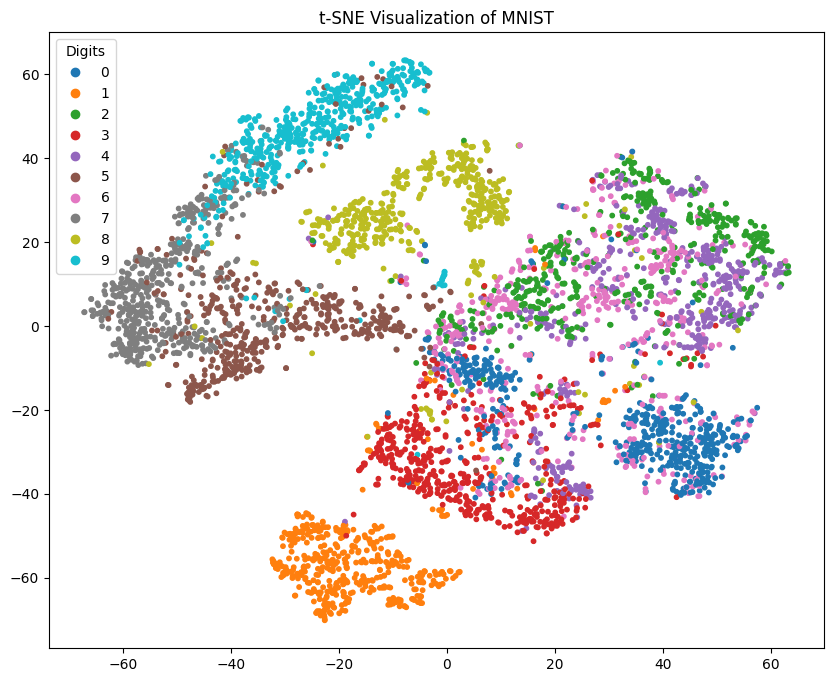

In [24]:
# Use a subset for speed (e.g., 5000 samples)
X_subset = X_scaled[:5000]
y_subset = y[:5000]

# t-SNE with updated parameter
tsne = TSNE(n_components=2, random_state=42, perplexity=30, max_iter=1000)
X_tsne = tsne.fit_transform(X_subset)

# Plot
plt.figure(figsize=(10,8))
scatter = plt.scatter(X_tsne[:,0], X_tsne[:,1], c=y_subset, cmap='tab10', s=10)
plt.legend(*scatter.legend_elements(), title="Digits")
plt.title("t-SNE Visualization of MNIST")
plt.show()

Task 12: Text Preprocessing – IMDB Movie Reviews
🔹 Introduction

Task Overview:
IMDB dataset contains movie reviews (text) labeled as positive or negative. Preprocessing is essential to clean the text before feeding it into ML or NLP models.

Chosen Techniques & Reason:

Lowercasing: Standardize text.

Removing punctuation & numbers: Remove noise.

Stopword removal: Remove common words that add little meaning.

Stemming/Lemmatization: Reduce words to base form for uniformity.

Tokenization: Split text into words/tokens.

This improves model performance and reduces vocabulary size.

In [33]:
import pandas as pd
import re

# Load IMDB dataset (adjust path if needed)
df = pd.read_csv("/kaggle/input/datasets/vishakhdapat/imdb-movie-reviews/IMDB Dataset.csv")
df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [41]:
df['review_clean'] = df['review'].str.lower()

In [42]:
def clean_text(text):
    text = re.sub(r'<.*?>', '', text)       # Remove HTML
    text = re.sub(r'\d+', '', text)         # Remove numbers
    text = re.sub(r'[^\w\s]', '', text)     # Remove punctuation
    return text

df['review_clean'] = df['review_clean'].apply(clean_text)

In [43]:
# Offline stopwords list (common English stopwords)
stop_words = set([
    'i','me','my','myself','we','our','ours','ourselves','you','your','yours','yourself','yourselves',
    'he','him','his','himself','she','her','hers','herself','it','its','itself','they','them','their',
    'theirs','themselves','what','which','who','whom','this','that','these','those','am','is','are','was',
    'were','be','been','being','have','has','had','having','do','does','did','doing','a','an','the','and',
    'but','if','or','because','as','until','while','of','at','by','for','with','about','against','between',
    'into','through','during','before','after','above','below','to','from','up','down','in','out','on','off',
    'over','under','again','further','then','once','here','there','when','where','why','how','all','any',
    'both','each','few','more','most','other','some','such','no','nor','not','only','own','same','so',
    'than','too','very','s','t','can','will','just','don','should','now'
])

# Tokenization using simple split
def tokenize_remove_stopwords(text):
    tokens = text.split()  # split by whitespace
    tokens = [word for word in tokens if word not in stop_words]
    return tokens

df['review_tokens'] = df['review_clean'].apply(tokenize_remove_stopwords)

In [44]:
# Minimal stemming/lemmatization without NLTK
# Optional: you can just keep tokens as is for offline vectorization

# Example: simple suffix stripping for common verb endings (basic stemming)
def simple_stem(tokens):
    return [word.rstrip('ing').rstrip('ed').rstrip('s') for word in tokens]

df['review_stemmed'] = df['review_tokens'].apply(simple_stem)

In [45]:
df['review_final'] = df['review_stemmed'].apply(lambda x: ' '.join(x))
df[['review', 'sentiment', 'review_final']].head()

,review,sentiment,review_final
0,One of the other reviewers has mentioned that ...,positive,on reviewer mention watch oz episo youll hook ...
1,A wonderful little production. <br /><br />The...,positive,wonderful littl productio film techniqu unassu...
2,I thought this was a wonderful way to spend ti...,positive,thought wonderful way spen tim hot summer week...
3,Basically there's a family where a little boy ...,negative,basically there family littl boy jak think the...
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive,petter mattei lov tim money visually stu film ...


Task 13: Time-Series Preprocessing – Air Quality Dataset

🔹 Introduction

Task Overview:
The Air Quality dataset contains timestamped measurements of air pollutants and environmental factors. Time-series preprocessing is essential to handle missing timestamps, irregular intervals, and noisy data before using it in forecasting or ML models.

Chosen Techniques & Reason:

Handling missing timestamps: Ensures the time index is continuous for analysis and modeling.

Resampling: Aggregates data at regular intervals (hourly/daily) to standardize frequency.

Smoothing (e.g., rolling mean): Reduces noise and reveals trends or patterns.

Interpolation: Fills missing values intelligently based on nearby data points.

These preprocessing steps prepare the dataset for accurate modeling, reduce noise, and make temporal patterns more apparent for analysis or prediction.

In [55]:
# Task 13: Fixed Time-Series Preprocessing – Air Quality Dataset
import pandas as pd
import numpy as np

# Correct reading: handle extra empty column at the end and proper separator
df = pd.read_csv(
    '/kaggle/input/datasets/dakshbhalala/uci-air-quality-dataset/AirQualityUCI.csv',
    sep=';', decimal=',', na_values=-200, engine='python'
)

# Drop completely empty columns (often the last one)
df = df.dropna(axis=1, how='all')

# Strip column names
df.columns = df.columns.str.strip()

# Inspect first rows
print(df.head())
print(df.columns)

# Combine Date and Time into datetime
df['Datetime'] = pd.to_datetime(df['Date'] + ' ' + df['Time'], dayfirst=True, errors='coerce')

# Drop rows with invalid datetime
df = df.dropna(subset=['Datetime'])

# Set datetime as index and drop original columns
df.set_index('Datetime', inplace=True)
df.drop(['Date', 'Time'], axis=1, inplace=True)

# Interpolate missing values
df_interpolated = df.interpolate(method='time')

# Optional: smoothing
df_smoothed = df_interpolated.rolling(window=3, min_periods=1).mean()

# Check result
print(df_smoothed.head())
print("Missing values after preprocessing:\n", df_smoothed.isnull().sum())

  Date,Time,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH,,
0  3/10/2004,18:00:00,2.6,1360,150,11.9,1046,166,...                                                                          
1  3/10/2004,19:00:00,2,1292,112,9.4,955,103,1174...                                                                          
2  3/10/2004,20:00:00,2.2,1402,88,9.0,939,131,114...                                                                          
3  3/10/2004,21:00:00,2.2,1376,80,9.2,948,172,109...                                                                          
4  3/10/2004,22:00:00,1.6,1272,51,6.5,836,131,120...                                                                          
Index(['Date,Time,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH,,'], dtype='object')


KeyError: 'Date'